# Image Classification using MobileNetV2 Transfer Learning

## Project Overview

This project builds a multi-class image classification model using **TensorFlow** and **MobileNetV2** through transfer learning.

The objective is to classify clothing images into different categories by leveraging a pretrained CNN instead of training a model from scratch.

## Technologies Used

* Python
* TensorFlow/Keras
* MobileNetV2
* NumPy
* Matplotlib

## Workflow

1. Load dataset
2. Preprocess images
3. Apply data augmentation
4. Build MobileNetV2 transfer learning model
5. Train the model
6. Evaluate performance
7. Predict unseen images


## Step 1: Import Required Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import random

In [2]:
# Dataset paths
clothes_path_train = "dataset/train"
clothes_path_val = "dataset/validation"
test_path = "dataset/test"

In [3]:
# Display class labels
print("Clothes Class Labels:", sorted(os.listdir(clothes_path_train)))
print("Clothes Class Labels:", sorted(os.listdir(clothes_path_val)))

Clothes Class Labels: ['blazer', 'jeans', 'shirt', 'shorts', 'skirt', 'tshirt']
Clothes Class Labels: ['blazer', 'jeans', 'shirt', 'shorts', 'skirt', 'tshirt']


## Dataset Exploration and Quality Check


In [4]:
from pathlib import Path
import pandas as pd

train_dir = Path(clothes_path_train)
val_dir = Path(clothes_path_val)
test_dir = Path(test_path)

dataset_info = []

for class_folder in sorted(train_dir.iterdir()):
    if class_folder.is_dir():
        class_name = class_folder.name

        train_count = len(list(class_folder.glob("*")))
        val_count = len(list((val_dir / class_name).glob("*")))
        test_count = len(list((test_dir / class_name).glob("*")))

        dataset_info.append({
            "Class": class_name,
            "Train": train_count,
            "Validation": val_count,
            "Test": test_count,
            "Total": train_count + val_count + test_count
        })

df = pd.DataFrame(dataset_info)

display(df)

print(f"\nTotal Images: {df['Total'].sum()}")
print(f"Number of Classes: {len(df)}")

,Class,Train,Validation,Test,Total
0,blazer,350,75,75,500
1,jeans,350,75,75,500
2,shirt,350,75,75,500
3,shorts,350,75,75,500
4,skirt,350,75,75,500
5,tshirt,350,75,75,500



Total Images: 3000
Number of Classes: 6


## Plot Class Distribution

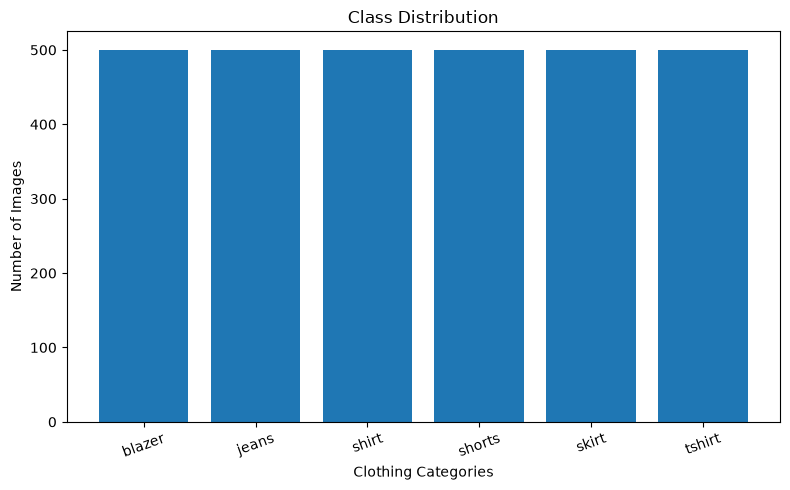

In [5]:
plt.figure(figsize=(8,5))

plt.bar(df["Class"], df["Total"])

plt.title("Class Distribution")
plt.xlabel("Clothing Categories")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## Visualizing Sample Images


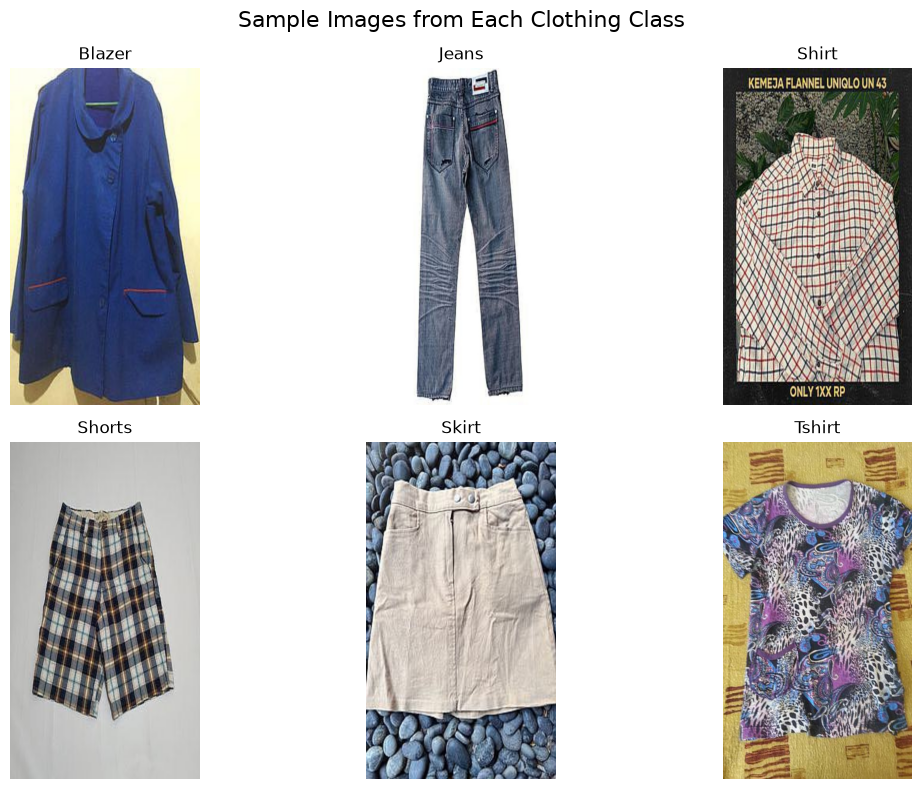

In [6]:
from PIL import Image

classes = sorted(os.listdir(clothes_path_train))

fig, axes = plt.subplots(2, 3, figsize=(12,8))
axes = axes.flatten()

for ax, cls in zip(axes, classes):
    img_path = os.path.join(
        clothes_path_train,
        cls,
        random.choice(os.listdir(os.path.join(clothes_path_train, cls)))
    )

    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(cls.capitalize())
    ax.axis("off")

plt.suptitle("Sample Images from Each Clothing Class", fontsize=16)
plt.tight_layout()
plt.show()

## Data Preprocessing and Augmentation


In [36]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.20,

    shear_range=0.10,
    brightness_range=[0.8, 1.2],

    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    clothes_path_train,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

validation_generator = val_test_datagen.flow_from_directory(
    clothes_path_val,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 2100 images belonging to 6 classes.
Found 450 images belonging to 6 classes.
Found 450 images belonging to 6 classes.


## Building the Transfer Learning Model


In [37]:
# Load pretrained MobileNetV2 without its original classifier
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

# Build custom classifier
inputs = Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(6, activation="softmax")(x)

model = Model(inputs, outputs)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Display architecture
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │           7,686 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Model Training


In [38]:
# Stop training if validation loss doesn't improve
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.5786 - loss: 1.1135 - val_accuracy: 0.7511 - val_loss: 0.7072
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.7967 - loss: 0.5879 - val_accuracy: 0.7667 - val_loss: 0.6445
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.8129 - loss: 0.5085 - val_accuracy: 0.7933 - val_loss: 0.5834
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.8490 - loss: 0.4289 - val_accuracy: 0.7800 - val_loss: 0.5981
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.8600 - loss: 0.4025 - val_accuracy: 0.8000 - val_loss: 0.5860
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8724 - loss: 0.3655 - val_accuracy: 0.7867 - val_loss: 0.6236


## Training Performance


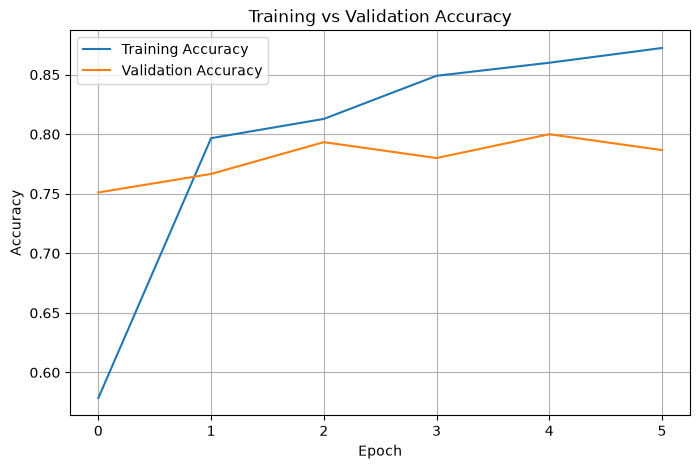

In [39]:
# Plot Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

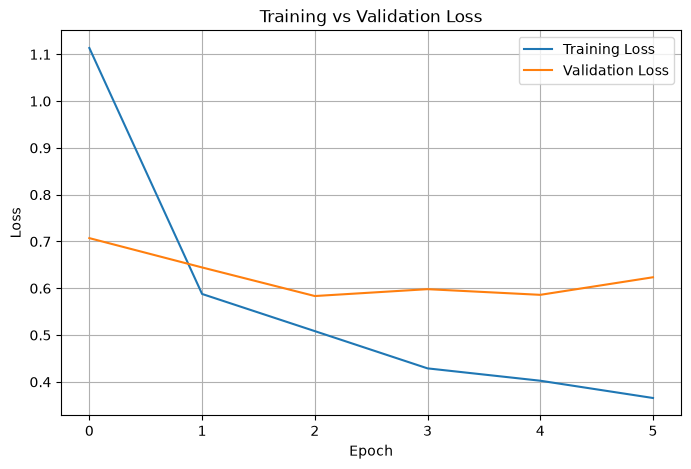

In [40]:
# Plot Loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Training Observation

* The model was initially trained using a frozen MobileNetV2 feature extractor.
* Training accuracy steadily increased from approximately **61%** to **89%**.
* Validation accuracy peaked at approximately **79%** and then plateaued.
* Validation loss reached its lowest value around **Epoch 3** before increasing slightly.
* This pattern indicates that the model began to overfit after the initial learning phase, making this a suitable baseline before fine-tuning the pretrained layers.


## Model Evaluation


In [41]:
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 712ms/step - accuracy: 0.7911 - loss: 0.5549
Test Loss: 0.5549
Test Accuracy: 0.7911


In [42]:
# Generate Predictions
import numpy as np

test_generator.reset()

predictions = model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

class_names = list(test_generator.class_indices.keys())

15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 803ms/step


In [43]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

      blazer       0.77      0.91      0.83        75
       jeans       0.91      0.68      0.78        75
       shirt       0.78      0.72      0.75        75
      shorts       0.65      0.80      0.72        75
       skirt       0.83      0.69      0.75        75
      tshirt       0.87      0.95      0.90        75

    accuracy                           0.79       450
   macro avg       0.80      0.79      0.79       450
weighted avg       0.80      0.79      0.79       450



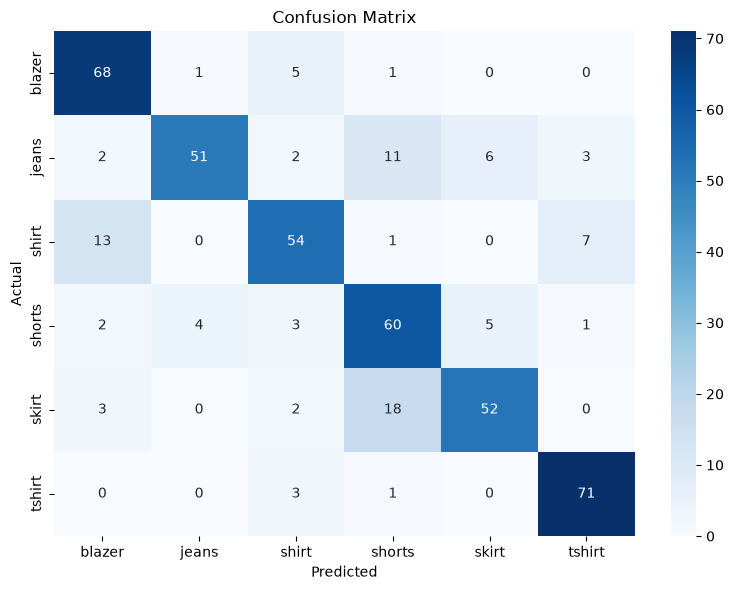

In [44]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

# Save the figure
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=300)

# Display it
plt.show()

## Stage 2: Two-Stage Fine-Tuning


In [47]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [48]:
# Unfreeze the top MobileNetV2 layers
# Unfreeze MobileNetV2
base_model.trainable = True

# Freeze first 130 layers
fine_tune_at = 130

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print("Trainable layers:",
      len([layer for layer in base_model.layers if layer.trainable]))

Trainable layers: 24


In [49]:
# Recompile the SAME model

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [50]:
# Create the learning-rate scheduler

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [51]:
# Continue training (this is the actual Stage 2)

history_stage2 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=8,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 205s 3s/step - accuracy: 0.7262 - loss: 0.7584 - val_accuracy: 0.8022 - val_loss: 0.5686 - learning_rate: 1.0000e-05
Epoch 2/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.7781 - loss: 0.6260 - val_accuracy: 0.8133 - val_loss: 0.5521 - learning_rate: 1.0000e-05
Epoch 3/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.8133 - loss: 0.5321 - val_accuracy: 0.8200 - val_loss: 0.5400 - learning_rate: 1.0000e-05
Epoch 4/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.8310 - loss: 0.4863 - val_accuracy: 0.8178 - val_loss: 0.5354 - learning_rate: 1.0000e-05
Epoch 5/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.8500 - loss: 0.4346 - val_accuracy: 0.8200 - val_loss: 0.5296 - learning_rate: 1.0000e-05
Epoch 6/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 2203s 34s/step - accuracy: 0.8529 - loss: 0.4214 - val_accuracy: 0.8156 - val_loss: 0.5271 - learning_rate: 1.0000e-05
Epoch 7/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.8762 - los

In [52]:
# Evaluate

test_loss_stage2, test_accuracy_stage2 = model.evaluate(test_generator)

print(f"Stage 2 Test Loss: {test_loss_stage2:.4f}")
print(f"Stage 2 Test Accuracy: {test_accuracy_stage2:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.8244 - loss: 0.4634
Stage 2 Test Loss: 0.4634
Stage 2 Test Accuracy: 0.8244


In [53]:
# Classification Report
test_generator.reset()

predictions_stage2 = model.predict(test_generator)

predicted_classes_stage2 = np.argmax(predictions_stage2, axis=1)
true_classes = test_generator.classes

print(classification_report(
    true_classes,
    predicted_classes_stage2,
    target_names=class_names
))

15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step
              precision    recall  f1-score   support

      blazer       0.78      0.85      0.82        75
       jeans       0.96      0.72      0.82        75
       shirt       0.80      0.75      0.77        75
      shorts       0.79      0.79      0.79        75
       skirt       0.77      0.85      0.81        75
      tshirt       0.88      0.99      0.93        75

    accuracy                           0.82       450
   macro avg       0.83      0.82      0.82       450
weighted avg       0.83      0.82      0.82       450



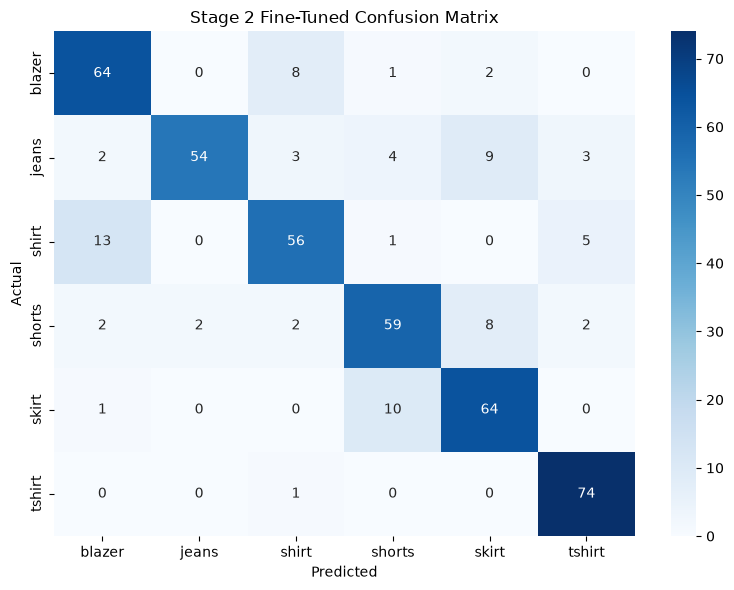

In [54]:
# Confusion Matrix
cm_stage2 = confusion_matrix(true_classes, predicted_classes_stage2)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_stage2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stage 2 Fine-Tuned Confusion Matrix")

plt.tight_layout()
plt.show()

## Final Model Selection

The final model was selected after comparing four different training strategies using test accuracy, classification reports, and confusion matrices.

The best-performing approach combined **stronger data augmentation**, **two-stage transfer learning with MobileNetV2**, and **ReduceLROnPlateau** for adaptive learning-rate scheduling, achieved the highest test accuracy of 82.44%, outperforming the baseline model by 4.44 percentage points while producing more balanced class-wise performance.

### Final Performance

* **Test Accuracy:** **82.44%**
* **Test Loss:** **0.4634**
* **Macro Precision:** **0.83**
* **Macro Recall:** **0.82**
* **Macro F1-score:** **0.82**

Compared to the baseline MobileNetV2 model (**78.00%**), the final approach improved test accuracy by **4.44 percentage points** while producing more balanced class-wise predictions across all six clothing categories.


## Experiment Summary

| Experiment       | Strategy                                                               | Test Accuracy | Observation                                                                                    |
| ---------------- | ---------------------------------------------------------------------- | ------------: | ---------------------------------------------------------------------------------------------- |
| **Baseline**     | Frozen MobileNetV2                                                     |    **78.00%** | Strong baseline with good overall generalization.                                              |
| **Experiment 2** | Fine-tuning from Layer 120                                             |    **77.80%** | Improved Shirt and Shorts but slightly reduced overall accuracy.                               |
| **Experiment 3** | Fine-tuning from Layer 140                                             |    **74.40%** | Performance dropped, indicating this fine-tuning strategy did not generalize well.             |
| **Final Model**  | Stronger Data Augmentation + Two-Stage Fine-Tuning + ReduceLROnPlateau |    **82.44%** | Best-performing model with the highest test accuracy and more balanced class-wise performance. |

## Final Conclusion

The project followed an iterative experimentation approach by evaluating multiple fine-tuning strategies instead of relying on a single model. Each experiment was compared using test accuracy, classification reports, and confusion matrices to identify the most effective approach. The final model combined stronger data augmentation with two-stage transfer learning and learning-rate scheduling, improving the test accuracy from **78.00%** to **82.44%**, a gain of **4.44 percentage points** over the baseline.
